# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>|
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [1]:
#from IPython.display import IFrame
#IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [2]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import json

from pathlib import Path
from bs4 import BeautifulStoneSoup as bs


## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [3]:
#creamos la carpeta data
crear = Path("data")
crear.mkdir(parents=True, exist_ok=True)

#api key    (segun las intrucciones el codigo debe ser utilizable en cualquier entorno por lo cual debe mostrarse una practica no aceptada)
headers = {"X-eBirdApiToken": "9ep9rnd5kroj"}#generalmente se guardan en un entorno aparte...


inicio = datetime.date(2022 ,2 , 1)
fin = datetime.date(2025 ,7 , 31)
actual = inicio

pull_list = []
while actual <= fin:
    day = actual.day
    month = actual.month
    year = actual.year
    url = f"https://api.ebird.org/v2/data/obs/CL/historic/{year}/{month}/{day}"
    try:
        pull = requests.get(url, headers= headers, timeout = 5)
        if pull.status_code == 200:
            datos = pull.json()
            pull_list.append(datos)
            actual+= datetime.timedelta(days=1)
        
            ruta_archivo = f"data/datos{year}_{month}_{day}.json"
            with open(ruta_archivo, 'w', encoding='utf-8') as archivo:
                json.dump(datos, archivo, ensure_ascii=False, indent=4)
            #print("agregado")
        else:
            datos = {"Encontrado": "Falso"}
            ruta_archivo = f"data/faltante{year}_{month}_{day}.json"
        
            with open(ruta_archivo, 'w', encoding='utf-8') as archivo:
                json.dump(datos, archivo, ensure_ascii=False, indent=4)
            #print("se demoro mucho")
            actual+= datetime.timedelta(days=1)
    except:
        none
        
        

NameError: name 'none' is not defined

In [ ]:
inicio = datetime.date(2022 ,2 , 1)
fin = datetime.date(2025 ,7 , 31)##2025-07-31
actual = inicio
lista =[]

#recorremos los datos descargados 
while actual <= fin:
    day = actual.day
    month = actual.month
    year = actual.year

    with open(f"data/datos{year}_{month}_{day}.json", 'r', encoding='utf-8') as archivo:
        archivos = json.load(archivo)
        for x in archivos:
            lista.append(x)    
        actual+= datetime.timedelta(days=1)


In [ ]:
guardar = pd.DataFrame(lista)## hacemos un dataframe 
#guardar.head()

name = "bigdata.csv"
guardar.to_csv(name, index= False, sep= ";",encoding='utf-8-sig')# guardamos el nuevo archivo

In [4]:
###Cargar datos ya descargados### si ya estan descargados correr aquiii 
df = pd.read_csv('bigdata.csv', sep=';')
df.columns

Index(['speciesCode', 'comName', 'sciName', 'locId', 'locName', 'obsDt',
       'howMany', 'lat', 'lng', 'obsValid', 'obsReviewed', 'locationPrivate',
       'subId', 'exoticCategory'],
      dtype='object')

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

In [5]:
# Respuesta a
df.columns =["Codigo Especie","Nomobre Ave","Nombre Cientifico","locId","Lugar","Dia Observacion","Cantidad Vistos","lat","lng","obsValid","Reseña Observacion","locPrivate","subId","categoria Exotica"]
df.columns


Index(['Codigo Especie', 'Nomobre Ave', 'Nombre Cientifico', 'locId', 'Lugar',
       'Dia Observacion', 'Cantidad Vistos', 'lat', 'lng', 'obsValid',
       'Reseña Observacion', 'locPrivate', 'subId', 'categoria Exotica'],
      dtype='object')

In [6]:
conteo =  df["Cantidad Vistos"].sum()
print(f"Hay un total de {conteo} avistamientos, vs los {len(df)} registros.")

Hay un total de 3259619.0 avistamientos, vs los 266009 registros.


In [7]:
# Respuesta b
sp = df["Cantidad Vistos"].copy()
aves =sp.value_counts()
print(f"Tenemos en total {len(aves)} tipos de aves registradas")

smt = df.groupby("Nomobre Ave")["Cantidad Vistos"].sum()
kt =smt.sort_values(ascending = True)
print(f"\nTop 5 aves mas vistas: {kt.tail()}")

Tenemos en total 537 tipos de aves registradas

Top 5 aves mas vistas: Nomobre Ave
Gray Gull           116566.0
Hudsonian Godwit    120524.0
Guanay Cormorant    127454.0
Sanderling          132619.0
Sooty Shearwater    458521.0
Name: Cantidad Vistos, dtype: float64


In [8]:
kt.describe()

count       533.000000
mean       6115.607880
std       24594.672746
min           0.000000
25%          62.000000
50%         982.000000
75%        3732.000000
max      458521.000000
Name: Cantidad Vistos, dtype: float64

In [9]:
df

,Codigo Especie,Nomobre Ave,Nombre Cientifico,locId,Lugar,Dia Observacion,Cantidad Vistos,lat,lng,obsValid,Reseña Observacion,locPrivate,subId,categoria Exotica
0,soulap1,Southern Lapwing,Vanellus chilensis,L4777617,Osorno,2022-02-01 23:56,1.0,-40.572419,-73.135986,True,False,False,S101876659,NaN
1,slbpar1,Slender-billed Parakeet,Enicognathus leptorhynchus,L4777617,Osorno,2022-02-01 23:54,1.0,-40.572419,-73.135986,True,False,False,S101876612,NaN
2,aupowl1,Austral Pygmy-Owl,Glaucidium nana,L8132006,RN Tamango--Camping y sendero Los Carpinteros,2022-02-01 22:10,1.0,-47.234412,-72.514052,True,False,False,S104489307,NaN
3,rulowl1,Rufous-legged Owl,Strix rufipes,L17621356,Camino cuatro esquinas,2022-02-01 22:02,1.0,-39.349522,-72.072421,True,False,True,S101873652,NaN
4,bcnher,Black-crowned Night Heron,Nycticorax nycticorax,L8206105,Playa Puerto Chico,2022-02-01 21:54,3.0,-41.326635,-72.966418,True,False,True,S101872461,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266004,wbctyr1,White-browed Chat-Tyrant,Ochthoeca leucophrys,L570508,Putre,2025-07-31 08:11,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN
266005,baytan3,Blue-and-yellow Tanager,Rauenia bonariensis,L570508,Putre,2025-07-31 08:11,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN
266006,bktflo1,Black-throated Flowerpiercer,Diglossa brunneiventris,L570508,Putre,2025-07-31 08:11,1.0,-18.196454,-69.556568,True,False,False,S263980121,NaN
266007,rngtyr1,Rufous-naped Ground-Tyrant,Muscisaxicola rufivertex,L39684723,"Coronel Alcerreca, Arica y Parinacota, CL (-17...",2025-07-31 07:47,4.0,-17.992459,-69.660757,True,False,True,S264055602,NaN


#### Respuesta B: 
#### La especie con mayor número de avistamientos es la pardela sombría (Ardenna grisea), con un total de 458.521 registros. Al observar el top 5 de las aves más vistas, que incluye también al zarapito de Hudson (Limosa haemastica) con 120.524, al cormorán guanay (Leucocarbo bougainvillii) con 127.454 y al playero blanco (Calidris alba) con 132.619, se puede notar un patrón claro: todas son aves costeras.

#### Esto sugiere que su hábitat preferido son las playas y zonas litorales, donde encuentran su principal fuente de alimento. Considerando la geografía de Chile, un país angosto con un extenso perímetro marítimo, es lógico que estas especies proliferen. El territorio nacional ofrece las condiciones ideales para que estas aves costeras prosperen, lo que explica la alta frecuencia de sus avistamientos.










#

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt(en mi casoDia Observacion)` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [10]:
# Respuesta
print(df["Dia Observacion"].dtype) ##esta como object

df["Dia Observacion"] = pd.to_datetime(df["Dia Observacion"], format="mixed")## uso de ia, sugerio format mixed

df["Dia Observacion"] = df["Dia Observacion"].dt.normalize()

df["month"] = df["Dia Observacion"].dt.month


object


In [11]:
df["Mes"] = df["Dia Observacion"].dt.month  # se agre mes
df["Mes y Dia"] = df["Dia Observacion"].dt.strftime('%Y-%m')## se agrega dia y mes

In [12]:
df

,Codigo Especie,Nomobre Ave,Nombre Cientifico,locId,Lugar,Dia Observacion,Cantidad Vistos,lat,lng,obsValid,Reseña Observacion,locPrivate,subId,categoria Exotica,month,Mes,Mes y Dia
0,soulap1,Southern Lapwing,Vanellus chilensis,L4777617,Osorno,2022-02-01,1.0,-40.572419,-73.135986,True,False,False,S101876659,NaN,2,2,2022-02
1,slbpar1,Slender-billed Parakeet,Enicognathus leptorhynchus,L4777617,Osorno,2022-02-01,1.0,-40.572419,-73.135986,True,False,False,S101876612,NaN,2,2,2022-02
2,aupowl1,Austral Pygmy-Owl,Glaucidium nana,L8132006,RN Tamango--Camping y sendero Los Carpinteros,2022-02-01,1.0,-47.234412,-72.514052,True,False,False,S104489307,NaN,2,2,2022-02
3,rulowl1,Rufous-legged Owl,Strix rufipes,L17621356,Camino cuatro esquinas,2022-02-01,1.0,-39.349522,-72.072421,True,False,True,S101873652,NaN,2,2,2022-02
4,bcnher,Black-crowned Night Heron,Nycticorax nycticorax,L8206105,Playa Puerto Chico,2022-02-01,3.0,-41.326635,-72.966418,True,False,True,S101872461,NaN,2,2,2022-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266004,wbctyr1,White-browed Chat-Tyrant,Ochthoeca leucophrys,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07
266005,baytan3,Blue-and-yellow Tanager,Rauenia bonariensis,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07
266006,bktflo1,Black-throated Flowerpiercer,Diglossa brunneiventris,L570508,Putre,2025-07-31,1.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07
266007,rngtyr1,Rufous-naped Ground-Tyrant,Muscisaxicola rufivertex,L39684723,"Coronel Alcerreca, Arica y Parinacota, CL (-17...",2025-07-31,4.0,-17.992459,-69.660757,True,False,True,S264055602,NaN,7,7,2025-07


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [13]:
# Respuesta
#https://geopandas.org/en/stable/docs/user_guide.html

geometry = gpd.points_from_xy(df.lng, df.lat)
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

gdf

,Codigo Especie,Nomobre Ave,Nombre Cientifico,locId,Lugar,Dia Observacion,Cantidad Vistos,lat,lng,obsValid,Reseña Observacion,locPrivate,subId,categoria Exotica,month,Mes,Mes y Dia,geometry
0,soulap1,Southern Lapwing,Vanellus chilensis,L4777617,Osorno,2022-02-01,1.0,-40.572419,-73.135986,True,False,False,S101876659,NaN,2,2,2022-02,POINT (-73.13599 -40.57242)
1,slbpar1,Slender-billed Parakeet,Enicognathus leptorhynchus,L4777617,Osorno,2022-02-01,1.0,-40.572419,-73.135986,True,False,False,S101876612,NaN,2,2,2022-02,POINT (-73.13599 -40.57242)
2,aupowl1,Austral Pygmy-Owl,Glaucidium nana,L8132006,RN Tamango--Camping y sendero Los Carpinteros,2022-02-01,1.0,-47.234412,-72.514052,True,False,False,S104489307,NaN,2,2,2022-02,POINT (-72.51405 -47.23441)
3,rulowl1,Rufous-legged Owl,Strix rufipes,L17621356,Camino cuatro esquinas,2022-02-01,1.0,-39.349522,-72.072421,True,False,True,S101873652,NaN,2,2,2022-02,POINT (-72.07242 -39.34952)
4,bcnher,Black-crowned Night Heron,Nycticorax nycticorax,L8206105,Playa Puerto Chico,2022-02-01,3.0,-41.326635,-72.966418,True,False,True,S101872461,NaN,2,2,2022-02,POINT (-72.96642 -41.32664)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266004,wbctyr1,White-browed Chat-Tyrant,Ochthoeca leucophrys,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07,POINT (-69.55657 -18.19645)
266005,baytan3,Blue-and-yellow Tanager,Rauenia bonariensis,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07,POINT (-69.55657 -18.19645)
266006,bktflo1,Black-throated Flowerpiercer,Diglossa brunneiventris,L570508,Putre,2025-07-31,1.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,7,2025-07,POINT (-69.55657 -18.19645)
266007,rngtyr1,Rufous-naped Ground-Tyrant,Muscisaxicola rufivertex,L39684723,"Coronel Alcerreca, Arica y Parinacota, CL (-17...",2025-07-31,4.0,-17.992459,-69.660757,True,False,True,S264055602,NaN,7,7,2025-07,POINT (-69.66076 -17.99246)


### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [14]:
# Respuesta

gdf_regiones  = gpd.read_file('Regional.shp')
gdf_regiones 

,objectid,cir_sena,codregion,area_km,st_area_sh,st_length_,Region,geometry
0,1084,1,15,16866.819844,1.886869e+10,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-7727277.278 -1997230.768, -7726464...."
1,1085,2,1,42284.567484,4.830637e+10,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-7810213.515 -2298008.28, -781..."
2,1086,3,2,126071.431981,1.508452e+11,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-7870470.961 -2985679.186, -78..."
3,1087,15,12,133053.142345,3.581316e+11,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-7494057.535 -7542535.383, -74..."
4,1088,14,11,106703.377369,2.242743e+11,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-8413517.696 -6234055.255, -84..."
5,1089,4,3,75661.248635,9.643906e+10,2.401741e+06,Región de Atacama,"MULTIPOLYGON (((-7932747.768 -3311218.615, -79..."
6,1090,5,4,40575.901682,5.498082e+10,2.065933e+06,Región de Coquimbo,"MULTIPOLYGON (((-7963268.9 -3784870.143, -7963..."
7,1091,6,5,16322.970393,2.301475e+10,1.679609e+06,Región de Valparaíso,"MULTIPOLYGON (((-8991645.917 -3991821.789, -89..."
8,1092,7,13,15392.030737,2.225204e+10,1.064253e+06,Región Metropolitana de Santiago,"POLYGON ((-7873736.745 -3885505.642, -7873695...."
9,1093,13,10,48408.371357,8.771834e+10,7.874158e+06,Región de Los Lagos,"MULTIPOLYGON (((-8331768.181 -5403721.402, -83..."


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

In [15]:
# Respuesta

gdf_reproyectado = gdf.to_crs(gdf_regiones.crs)


avistamientos_con_region = gpd.sjoin(gdf_reproyectado, gdf_regiones, how="inner", predicate='within')
total_por_region = avistamientos_con_region.groupby('Region')['Cantidad Vistos'].sum()
gdf_regiones_con_datos = gdf_regiones.merge(total_por_region,left_on='Region',right_index=True,how='left')


gdf_regiones_con_datos['Cantidad Vistos'] = gdf_regiones_con_datos['Cantidad Vistos'].fillna(0)



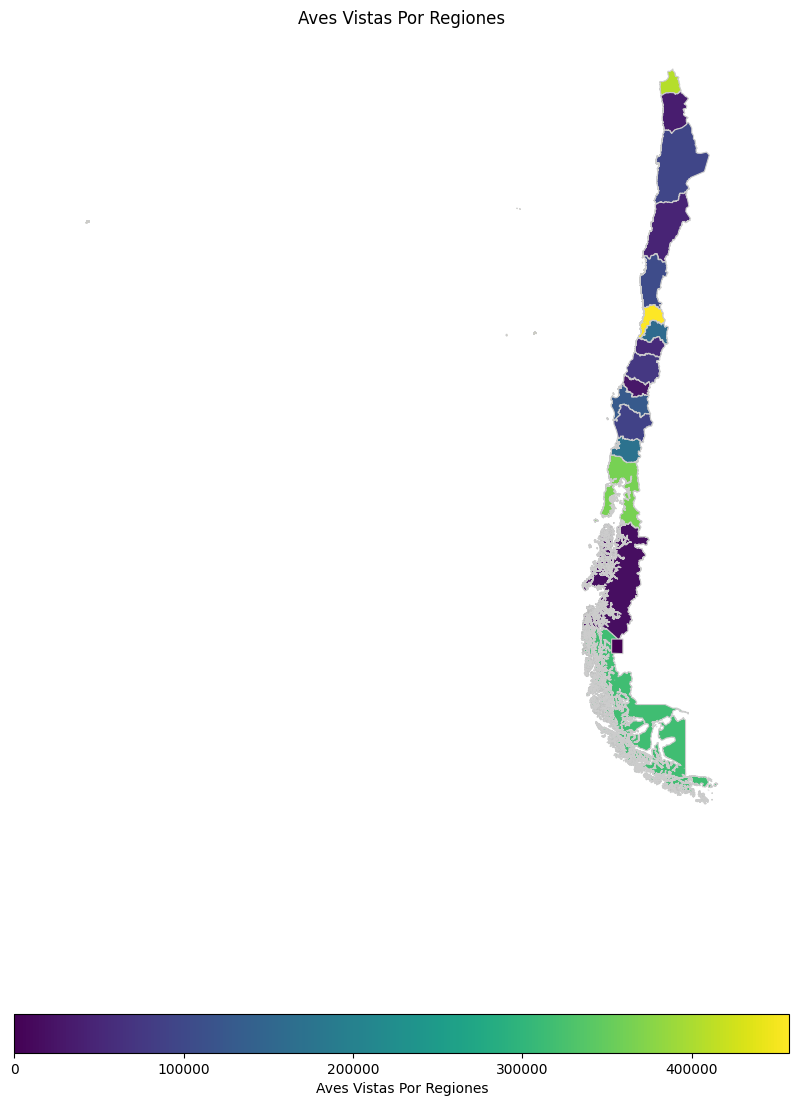

In [16]:

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
gdf_regiones_con_datos.plot(column='Cantidad Vistos',cmap='viridis',linewidth=0.8,ax=ax,edgecolor='0.8',legend=True,legend_kwds={'label': "Aves Vistas Por Regiones",'orientation': "horizontal"})
ax.set_title('Aves Vistas Por Regiones', fontsize=12)
ax.set_axis_off()
plt.show()


### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [17]:
# Respuesta
df_run = df[df['Nombre Cientifico'] == 'Hymenops perspicillatus'].copy()
df_dor = df[df['Nombre Cientifico'] == 'Muscisaxicola maclovianus'].copy()


In [18]:
#df_run

In [19]:
#df_dor

**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

In [20]:
# Respuesta
df_run['fecha'] = pd.to_datetime(df_run['Dia Observacion'])
df_run.set_index('fecha', inplace=True)
run_monthly = df_run.resample('ME').size()
df_run

df_dor['fecha'] = pd.to_datetime(df_dor['Dia Observacion'])
df_dor.set_index('fecha', inplace=True)
dor_monthly = df_dor.resample('ME').size()
#df_dor


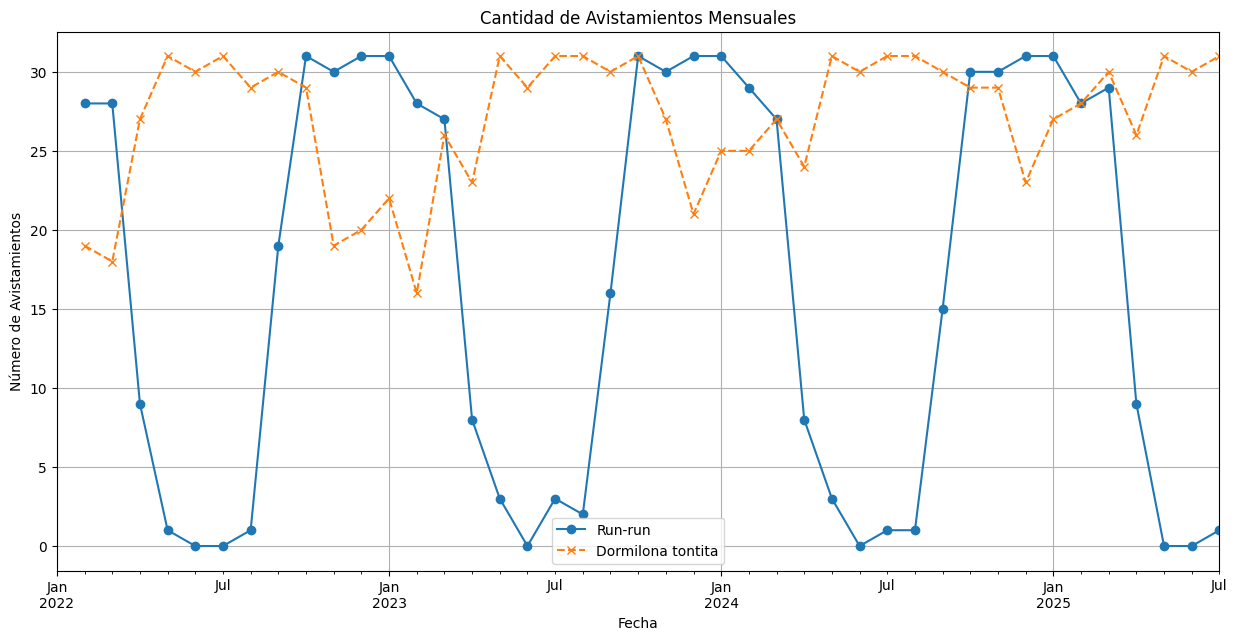

In [21]:

##https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
fig, ax = plt.subplots(figsize=(15, 7))
run_monthly.plot(ax=ax, label='Run-run', marker='o')
dor_monthly.plot(ax=ax, label='Dormilona tontita', marker='x', linestyle='--')
ax.set_title('Cantidad de Avistamientos Mensuales')
ax.set_ylabel('Número de Avistamientos')
ax.set_xlabel('Fecha')
ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-07-01')) 
ax.legend()      
ax.grid(True)


plt.show()


**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

In [22]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))



In [23]:
# Respuesta




**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta

# Promt utilizado para redaccion y escritura>
#### Lamento comentar que mi gramatica no es la mejor, por lo cual me ayude con IA para  la redaccion de ella, el analis sigue sindo mio, dejo los promts con texto original. Faltas de ortografia o redaccion no considerarlas en esta parte, fueron escritas intensamente en momentos de analiss, como un clasico borrador
Se utilizo Gemini 2.5 Pro

PROMT1: 

redactame mejor el siguente texto, pero no lo cambies, solo mejora la redaccion y un poco la gramatica, que siga siendo creado por mi, es solo correccion lo que te pido: #### Podemos ver que la ave mas vista es la Ardenna grisea(458.521 avistamientos), tambien conocida como Pardela sombría, y al igual |que las otras 5 que estan en el top,al buscarlas en google image, si saber de aves me doy cuenta que todas son de tipo costeras. Que les gusta la playa y se alimentan de los organismo que hay ahi. #### Por lo cual podemos decir que en el top 5(Hudsonian Godwit:120524--Guanay Cormorant---127454.0Sanderling:132619.0Sooty Shearwate 458521.0) son aves de tipo costeras, y Chile al ser angosto y con un gran perimetro maritimo, refuerza la idea que el avistamientos de estas aves sea porque Chile cumple las condiciones para proliferacion.

Output1:

Claro, aquí tienes una versión mejorada de tu texto, manteniendo tu idea original:

La especie con mayor número de avistamientos es la pardela sombría (Ardenna grisea), con un total de 458,521 registros. Al observar el top 5 de las aves más vistas, que incluye también al zarapito de Hudson (Limosa haemastica) con 120,524, al cormorán guanay (Leucocarbo bougainvillii) con 127,454 y al playero blanco (Calidris alba) con 132,619, se puede notar un patrón claro: todas son aves costeras.

Esto sugiere que su hábitat preferido son las playas y zonas litorales, donde encuentran su principal fuente de alimento. Considerando la geografía de Chile, un país angosto con un extenso perímetro marítimo, es lógico que estas especies proliferen. El territorio nacional ofrece las condiciones ideales para que estas aves costeras prosperen, lo que explica la alta frecuencia de sus avistamientos.